In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv("diamonds.csv")

df.head()

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [3]:
df.shape

(53940, 11)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  53940 non-null  int64  
 1   carat       53940 non-null  float64
 2   cut         53940 non-null  str    
 3   color       53940 non-null  str    
 4   clarity     53940 non-null  str    
 5   depth       53940 non-null  float64
 6   table       53940 non-null  float64
 7   price       53940 non-null  int64  
 8   x           53940 non-null  float64
 9   y           53940 non-null  float64
 10  z           53940 non-null  float64
dtypes: float64(6), int64(2), str(3)
memory usage: 4.5 MB


In [6]:
df.columns

Index(['Unnamed: 0', 'carat', 'cut', 'color', 'clarity', 'depth', 'table',
       'price', 'x', 'y', 'z'],
      dtype='str')

In [5]:
df.describe()

,Unnamed: 0,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,26970.500000,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,15571.281097,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,1.000000,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,13485.750000,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,26970.500000,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,40455.250000,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,53940.000000,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


In [7]:
df.isna().sum()

Unnamed: 0    0
carat         0
cut           0
color         0
clarity       0
depth         0
table         0
price         0
x             0
y             0
z             0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
(df[["x", "y", "z"]] == 0).sum()

x     8
y     7
z    20
dtype: int64

In [10]:
df[df[["x", "y", "z"]].eq(0).any(axis=1)]

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
2207,2208,1.00,Premium,G,SI2,59.1,59.0,3142,6.55,6.48,0.0
2314,2315,1.01,Premium,H,I1,58.1,59.0,3167,6.66,6.60,0.0
4791,4792,1.10,Premium,G,SI2,63.0,59.0,3696,6.50,6.47,0.0
5471,5472,1.01,Premium,F,SI2,59.2,58.0,3837,6.50,6.47,0.0
10167,10168,1.50,Good,G,I1,64.0,61.0,4731,7.15,7.04,0.0
11182,11183,1.07,Ideal,F,SI2,61.6,56.0,4954,0.00,6.62,0.0
11963,11964,1.00,Very Good,H,VS2,63.3,53.0,5139,0.00,0.00,0.0
13601,13602,1.15,Ideal,G,VS2,59.2,56.0,5564,6.88,6.83,0.0
15951,15952,1.14,Fair,G,VS1,57.5,67.0,6381,0.00,0.00,0.0
24394,24395,2.18,Premium,H,SI2,59.4,61.0,12631,8.49,8.45,0.0


In [11]:
df = df[(df["x"] > 0) & (df["y"] > 0) & (df["z"] > 0)]

In [12]:
df.shape

(53920, 11)

In [13]:
df = df.drop(columns=["Unnamed: 0"])

In [14]:
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [15]:
df.shape

(53920, 10)

In [16]:
df["price"].describe()

count    53920.000000
mean      3930.993231
std       3987.280446
min        326.000000
25%        949.000000
50%       2401.000000
75%       5323.250000
max      18823.000000
Name: price, dtype: float64

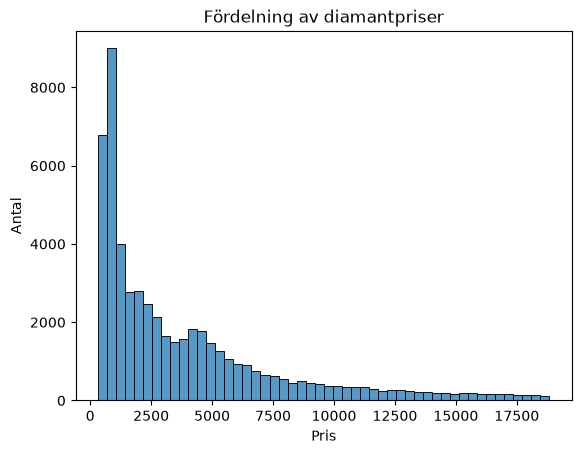

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(data=df, x="price", bins=50)
plt.title("Fördelning av diamantpriser")
plt.xlabel("Pris")
plt.ylabel("Antal")
plt.show()

Prisfördelningen är tydligt högerskev. De flesta diamanter har relativt låga priser, medan ett mindre antal diamanter har betydligt högre priser. Detta syns genom den långa svansen åt höger. Medelvärdet (cirka 3933) är därför betydligt högre än medianen (2401)

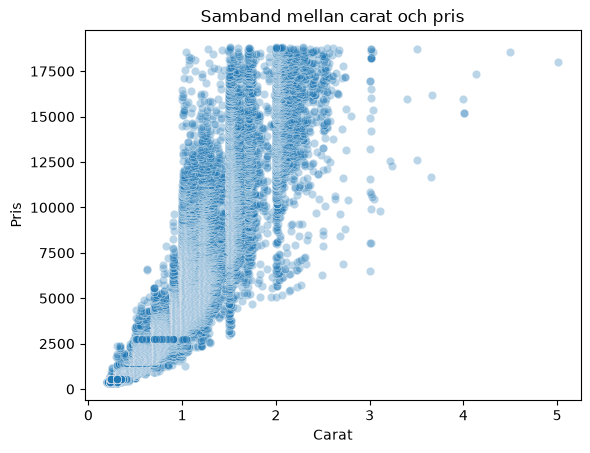

In [18]:
sns.scatterplot(data=df, x="carat", y="price", alpha=0.3)

plt.title("Samband mellan carat och pris")
plt.xlabel("Carat")
plt.ylabel("Pris")
plt.show()

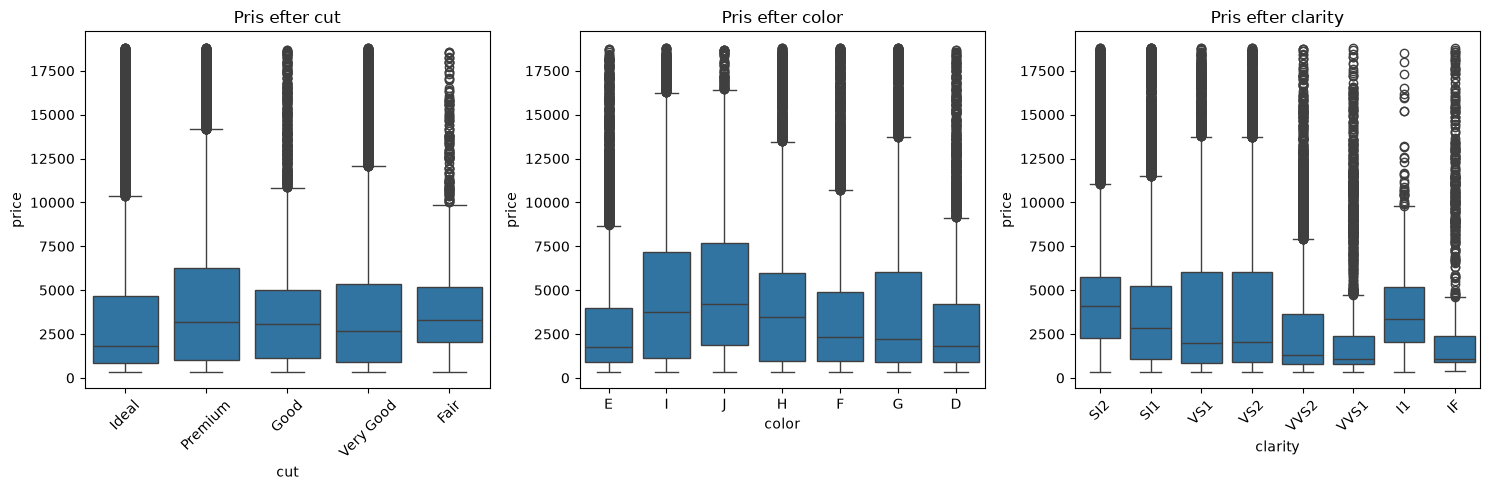

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.boxplot(data=df, x="cut", y="price", ax=axes[0])
axes[0].set_title("Pris efter cut")
axes[0].tick_params(axis="x", rotation=45)

sns.boxplot(data=df, x="color", y="price", ax=axes[1])
axes[1].set_title("Pris efter color")

sns.boxplot(data=df, x="clarity", y="price", ax=axes[2])
axes[2].set_title("Pris efter clarity")
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

In [20]:
X = df.drop(columns=["price"])
y = df["price"]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nFeatures:")
print(X.columns.tolist())

X shape: (53920, 9)
y shape: (53920,)

Features:
['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'x', 'y', 'z']


In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (43136, 9)
X_test: (10784, 9)
y_train: (43136,)
y_test: (10784,)


In [22]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

numeric_features = ["carat", "depth", "table", "x", "y", "z"]
categorical_features = ["cut", "color", "clarity"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [23]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", RandomForestRegressor(
            n_estimators=100,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['carat','cut','color',...,'x','y','z']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the outpu

In [26]:
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score

y_pred = model.predict(X_test)

rmse = root_mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse}")
print(f"MAE:  {mae}")
print(f"R²:   {r2}")

RMSE: 524.112392116348
MAE:  264.3654728923066
R²:   0.9828658532042527


In [28]:
from sklearn.linear_model import LinearRegression

linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", LinearRegression())
    ]
)

linear_model.fit(X_train, y_train)

y_pred_linear = linear_model.predict(X_test)

rmse_linear = root_mean_squared_error(y_test, y_pred_linear)
mae_linear = mean_absolute_error(y_test, y_pred_linear)
r2_linear = r2_score(y_test, y_pred_linear)

print(f"Linear Regression")
print(f"RMSE: {rmse_linear}")
print(f"MAE:  {mae_linear}")
print(f"R²:   {r2_linear}")

Linear Regression
RMSE: 1135.943716276348
MAE:  726.2998562076184
R²:   0.9195127194882521


In [29]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "regressor__n_estimators": [100, 200],
    "regressor__max_depth": [None, 20, 30]
}

grid_search = GridSearchCV(
    model,
    param_grid,
    cv=3,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Bästa parametrar:")
print(grid_search.best_params_)

print("\nBästa CV-RMSE:")
print(-grid_search.best_score_)

Bästa parametrar:
{'regressor__max_depth': 20, 'regressor__n_estimators': 200}

Bästa CV-RMSE:
570.4012755115937


In [30]:
best_model = grid_search.best_estimator_

y_pred_best = best_model.predict(X_test)

rmse_best = root_mean_squared_error(y_test, y_pred_best)
mae_best = mean_absolute_error(y_test, y_pred_best)
r2_best = r2_score(y_test, y_pred_best)

print(f"Optimized Random Forest")
print(f"RMSE: {rmse_best:.2f}")
print(f"MAE:  {mae_best:.2f}")
print(f"R²:   {r2_best:.4f}")

Optimized Random Forest
RMSE: 519.92
MAE:  263.25
R²:   0.9831


In [31]:
feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()

importances = best_model.named_steps["regressor"].feature_importances_

feature_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

print(feature_importance.head(15))

             feature  importance
0         num__carat    0.566646
4             num__y    0.318217
21  cat__clarity_SI2    0.019064
18   cat__clarity_I1    0.015607
20  cat__clarity_SI1    0.014269
17      cat__color_J    0.010379
16      cat__color_I    0.007685
23  cat__clarity_VS2    0.007315
3             num__x    0.006585
15      cat__color_H    0.005693
22  cat__clarity_VS1    0.005459
5             num__z    0.004976
1         num__depth    0.003045
11      cat__color_D    0.002773
14      cat__color_G    0.002477


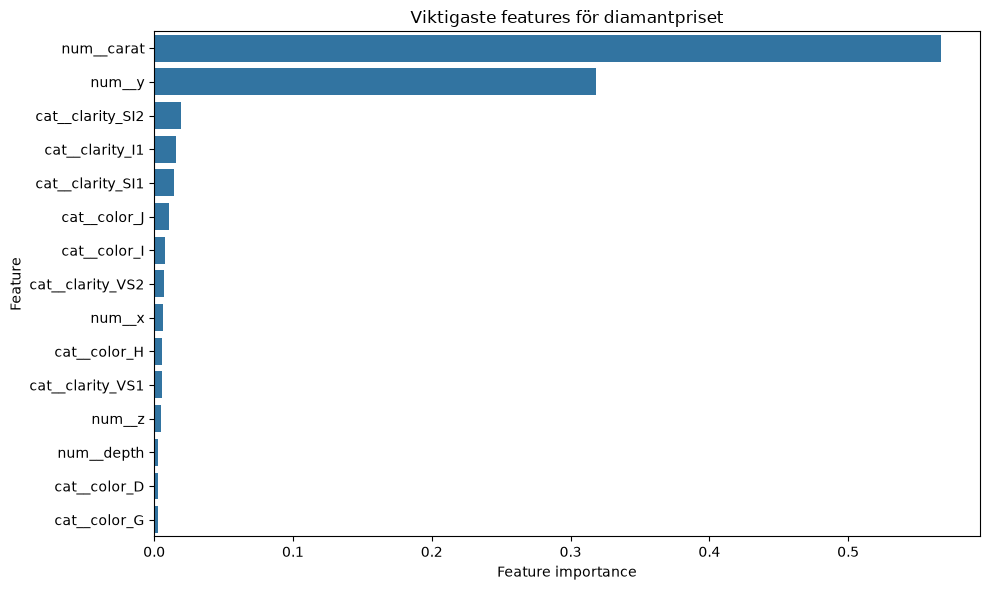

In [32]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance.head(15),
    x="importance",
    y="feature"
)

plt.title("Viktigaste features för diamantpriset")
plt.xlabel("Feature importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

Random Forest presterade bättre än Linear Regression för att förutsäga diamantpriser. Den optimerade Random Forest-modellen fick ett RMSE på 519,92, MAE på 263,25 och R² på 0,9831 på testdatan